In [6]:
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  fonts-nanum
0 upgraded, 1 newly installed, 0 to remove and 19 not upgraded.
Need to get 10.3 MB of archives.
After this operation, 34.1 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum all 20200506-1 [10.3 MB]
Fetched 10.3 MB in 0s (22.9 MB/s)
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 1.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Selecting previously unselected package fonts-nanum.
(Reading database ... 120874 files and direc

In [1]:
import matplotlib.pyplot as plt

plt.rc('font', family='NanumBarunGothic')

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
import pandas as pd

# CSV 파일 경로 설정
csv_file_path = "/content/drive/MyDrive/100만원/data/merge/total_to_merge2.csv"

# CSV 파일을 DataFrame으로 불러오기
df = pd.read_csv(csv_file_path, index_col=0)

In [4]:
df

,ENN_LNN_MTH_AVG,평균파주기_MTH_AVG,해면수온_MTH_AVG,해상기온_MTH_AVG,해상풍_MTH_AVG,해면기압_MTH_AVG,해빙부피_MTH_AVG
WTCH_YM,,,,,,,
198201,26.583536,8.484656,17.975416,16.2761,4.60747,1010.17,28.0830
198202,26.455164,8.624267,18.021090,16.4262,4.88813,1010.47,32.2594
198203,27.034367,8.682927,18.060934,16.4856,4.97067,1011.33,35.1276
198204,27.782887,8.776587,18.017712,16.3783,4.41675,1011.52,35.8904
198205,28.324877,8.290178,17.966919,16.5513,4.51024,1010.89,33.1089
...,...,...,...,...,...,...,...
202305,28.319105,8.753543,18.652569,17.2103,4.78082,1011.28,24.5053
202306,28.596712,8.373318,18.655016,17.2739,4.46231,1011.59,19.0704
202307,28.348682,8.339921,18.811852,17.3600,5.17453,1011.90,10.7976


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 501 entries, 198201 to 202309
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ENN_LNN_MTH_AVG  501 non-null    float64
 1   평균파주기_MTH_AVG    501 non-null    float64
 2   해면수온_MTH_AVG     501 non-null    float64
 3   해상기온_MTH_AVG     501 non-null    float64
 4   해상풍_MTH_AVG      501 non-null    float64
 5   해면기압_MTH_AVG     501 non-null    float64
 6   해빙부피_MTH_AVG     499 non-null    float64
dtypes: float64(7)
memory usage: 31.3 KB


/usr/local/lib/python3.10/dist-packages/seaborn/utils.py:80: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from current font.
  fig.canvas.draw()


<Axes: >

/usr/local/lib/python3.10/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from current font.
  func(*args, **kwargs)
/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


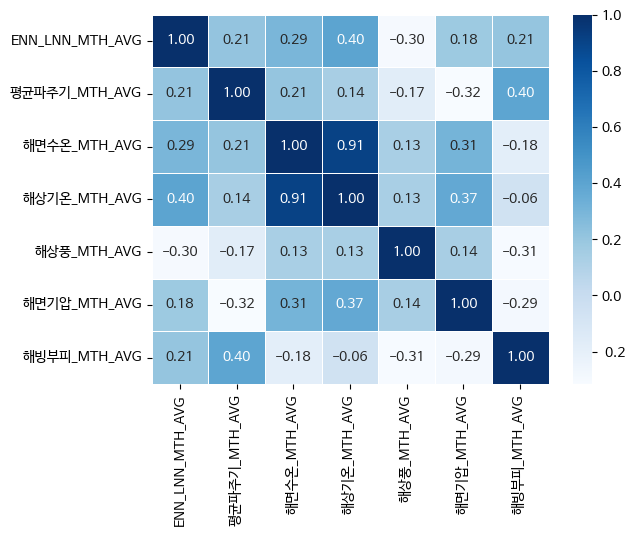

In [5]:
import seaborn as sns
sns.heatmap(data = df.corr(), annot=True, fmt = '.2f', linewidths=.5, cmap='Blues')

In [6]:
df = df.reset_index()

In [7]:
# "날짜" 열을 datetime 형식으로 변환
df["WTCH_YM"] = pd.to_datetime(df["WTCH_YM"], format="%Y%m")

In [8]:

df

,WTCH_YM,ENN_LNN_MTH_AVG,평균파주기_MTH_AVG,해면수온_MTH_AVG,해상기온_MTH_AVG,해상풍_MTH_AVG,해면기압_MTH_AVG,해빙부피_MTH_AVG
0,1982-01-01,26.583536,8.484656,17.975416,16.2761,4.60747,1010.17,28.0830
1,1982-02-01,26.455164,8.624267,18.021090,16.4262,4.88813,1010.47,32.2594
2,1982-03-01,27.034367,8.682927,18.060934,16.4856,4.97067,1011.33,35.1276
3,1982-04-01,27.782887,8.776587,18.017712,16.3783,4.41675,1011.52,35.8904
4,1982-05-01,28.324877,8.290178,17.966919,16.5513,4.51024,1010.89,33.1089
...,...,...,...,...,...,...,...,...
496,2023-05-01,28.319105,8.753543,18.652569,17.2103,4.78082,1011.28,24.5053
497,2023-06-01,28.596712,8.373318,18.655016,17.2739,4.46231,1011.59,19.0704
498,2023-07-01,28.348682,8.339921,18.811852,17.3600,5.17453,1011.90,10.7976
499,2023-08-01,28.169405,8.567650,18.955067,17.3312,4.77287,1011.85,6.2384


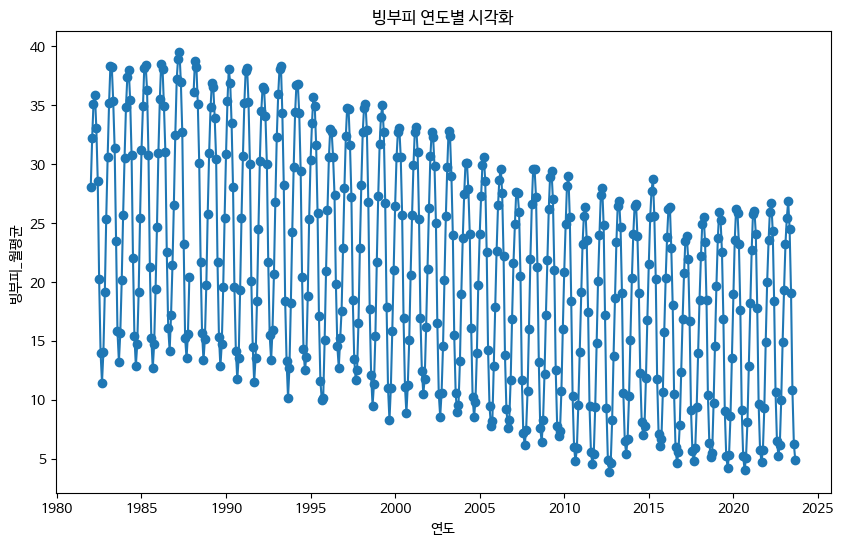

In [9]:
# 데이터 프레임에서 x와 y 데이터를 추출하세요
x = df["WTCH_YM"]
y = df["해빙부피_MTH_AVG"]

# 그래프를 생성하고 데이터를 플롯하세요
plt.figure(figsize=(10, 6))  # 그래프 크기 조정 (선택적)
plt.plot(x, y, marker='o', linestyle='-')
plt.title("빙부피 연도별 시각화")  # 그래프 제목 설정 (선택적)
plt.xlabel("연도")  # x축 레이블 설정 (선택적)
plt.ylabel("빙부피_월평균")  # y축 레이블 설정 (선택적)

# 그래프를 표시하세요
plt.show()

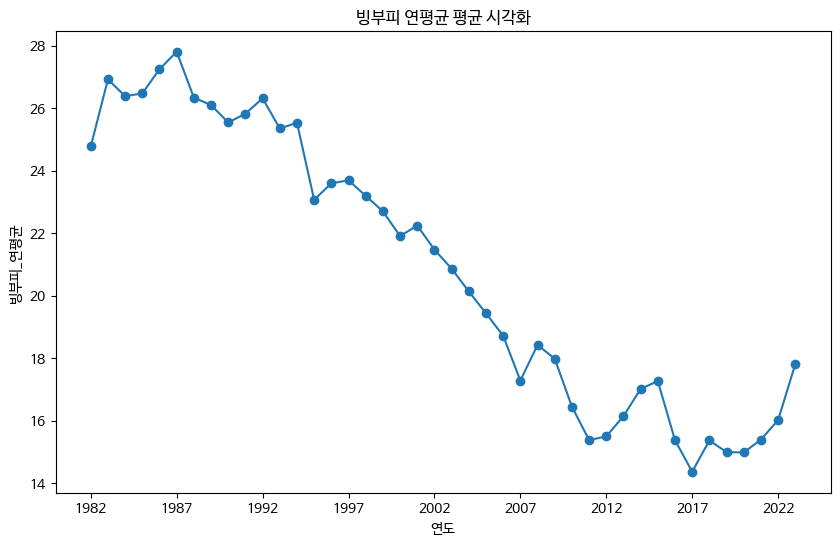

In [10]:
# 연도별로 그룹화하고 "해빙부피_MTH_AVG"의 평균을 계산(북극임)
yearly_data = df.groupby(df["WTCH_YM"].dt.year)["해빙부피_MTH_AVG"].mean()

# 그래프를 생성하고 데이터를 플롯하세요
plt.figure(figsize=(10, 6))  # 그래프 크기 조정 (선택적)
yearly_data.plot(marker='o', linestyle='-')
plt.title("빙부피 연평균 평균 시각화")  # 그래프 제목 설정 (선택적)
plt.xlabel("연도")  # x축 레이블 설정 (선택적)
plt.ylabel("빙부피_연평균")  # y축 레이블 설정 (선택적)

# x축 눈금을 5년 단위로 설정
years = range(df["WTCH_YM"].dt.year.min(), df["WTCH_YM"].dt.year.max() + 1, 5)
plt.xticks(years)

# 그래프를 표시하세요
plt.show()

<ipython-input-11-deced973c9ad>:15: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = plt.cm.get_cmap("viridis")


<Figure size 1000x600 with 0 Axes>

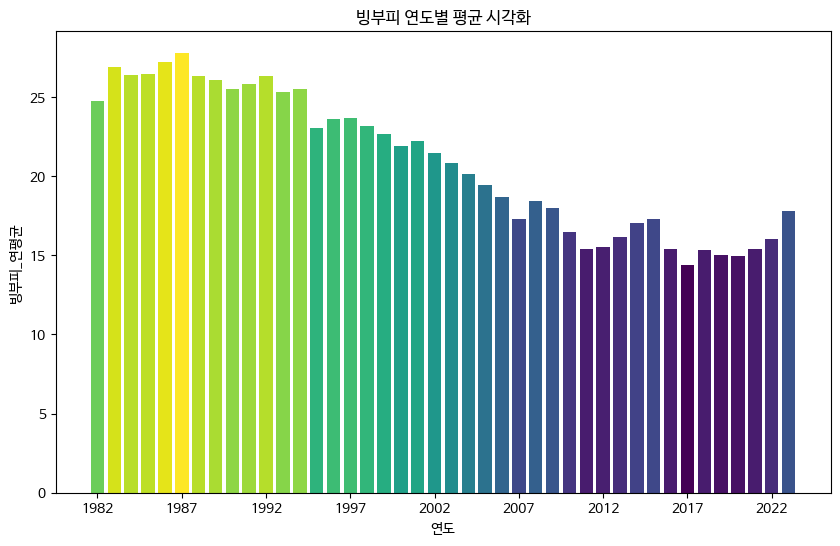

In [11]:
# 색상 그라데이션 함수
def gradient_color(data, cmap):
    norm = plt.Normalize(data.min(), data.max())
    colors = cmap(norm(data))
    return colors

# 그래프를 생성하고 데이터를 플롯하세요
plt.figure(figsize=(10, 6))  # 그래프 크기 조정 (선택적)


# 그래프를 생성하고 데이터를 플롯하세요
plt.figure(figsize=(10, 6))  # 그래프 크기 조정 (선택적)

# 색상 그라데이션 적용
cmap = plt.cm.get_cmap("viridis")
colors = gradient_color(yearly_data, cmap)

# 막대 그래프로 표시
plt.bar(yearly_data.index, yearly_data, color=colors)

# X 축 레이블을 5년 단위로 설정
years = range(yearly_data.index.min(), yearly_data.index.max() + 1, 5)
plt.xticks(years)

plt.title("빙부피 연도별 평균 시각화")  # 그래프 제목 설정 (선택적)
plt.xlabel("연도")  # x축 레이블 설정 (선택적)
plt.ylabel("빙부피_연평균")  # y축 레이블 설정 (선택적)

# 그래프를 표시하세요
plt.show()

<ipython-input-12-07cb8533b245>:8: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = plt.cm.get_cmap("viridis")
<ipython-input-12-07cb8533b245>:12: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(yearly_data.index, yearly_data, c=colors, cmap="viridis", s=50, marker='o')


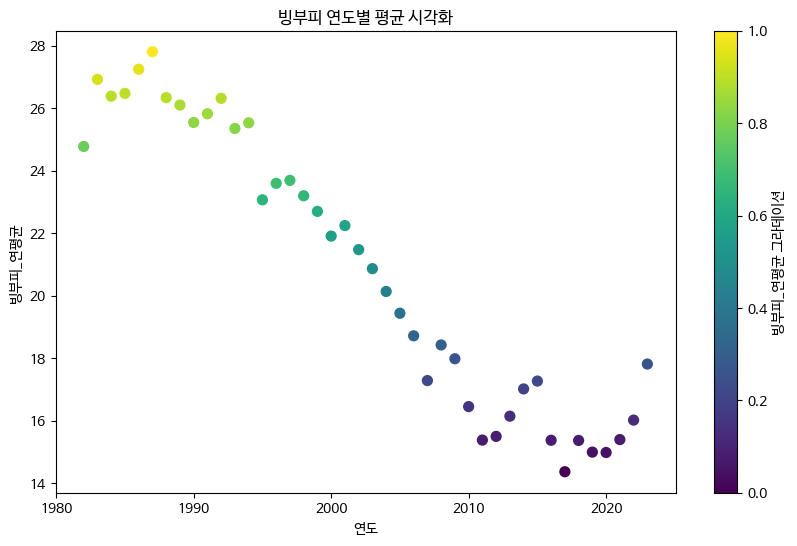

In [12]:
# 연도별로 그룹화하고 "해빙부피_MTH_AVG"의 평균을 계산
yearly_data = df.groupby(df["WTCH_YM"].dt.year)["해빙부피_MTH_AVG"].mean()

# 그래프를 생성하고 데이터를 산점도로 플롯하세요
plt.figure(figsize=(10, 6))  # 그래프 크기 조정 (선택적)

# 색상 그라데이션 적용
cmap = plt.cm.get_cmap("viridis")
colors = gradient_color(yearly_data, cmap)

# 산점도로 표시
plt.scatter(yearly_data.index, yearly_data, c=colors, cmap="viridis", s=50, marker='o')

plt.title("빙부피 연도별 평균 시각화")  # 그래프 제목 설정 (선택적)
plt.xlabel("연도")  # x축 레이블 설정 (선택적)
plt.ylabel("빙부피_연평균")  # y축 레이블 설정 (선택적)

# 컬러바 추가
cbar = plt.colorbar()
cbar.set_label("빙부피_연평균 그라데이션")

# 그래프를 표시하세요
plt.show()


<ipython-input-42-7df377e3742f>:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = plt.cm.get_cmap("viridis")
<ipython-input-42-7df377e3742f>:9: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(yearly_data.index, yearly_data, c=colors, cmap="viridis", s=50, marker='o')


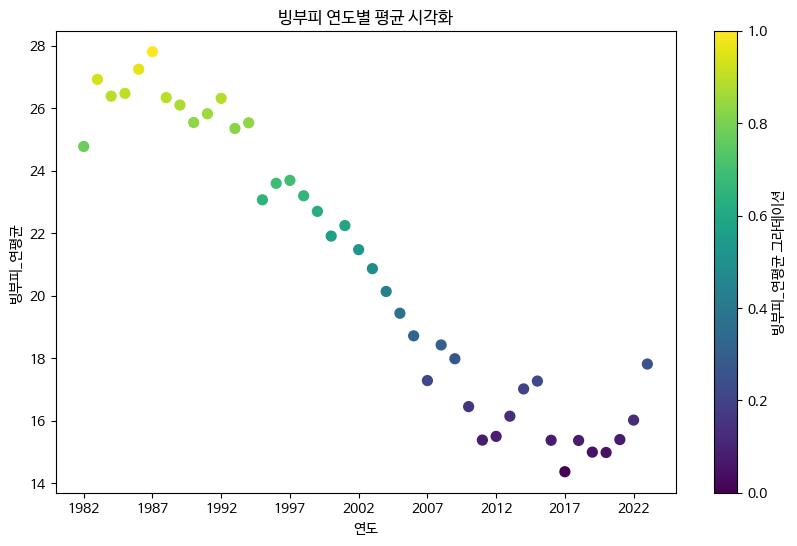

In [ ]:
# 그래프를 생성하고 데이터를 산점도로 플롯하세요
plt.figure(figsize=(10, 6))  # 그래프 크기 조정 (선택적)

# 색상 그라데이션 적용
cmap = plt.cm.get_cmap("viridis")
colors = gradient_color(yearly_data, cmap)

# 산점도로 표시
plt.scatter(yearly_data.index, yearly_data, c=colors, cmap="viridis", s=50, marker='o')

plt.title("빙부피 연도별 평균 시각화")  # 그래프 제목 설정 (선택적)
plt.xlabel("연도")  # x축 레이블 설정 (선택적)
plt.ylabel("빙부피_연평균")  # y축 레이블 설정 (선택적)

# X 축 눈금을 5년 주기로 설정
years = range(yearly_data.index.min(), yearly_data.index.max() + 1, 5)
plt.xticks(years)

# 컬러바 추가
cbar = plt.colorbar()
cbar.set_label("빙부피_연평균 그라데이션")

# 그래프를 표시하세요
plt.show()


<ipython-input-13-0457402f5aa8>:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = plt.cm.get_cmap("viridis")
<ipython-input-13-0457402f5aa8>:9: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(yearly_data.index, yearly_data, c=colors, cmap="viridis", s=50, marker='o', label="빙부피_연평균")


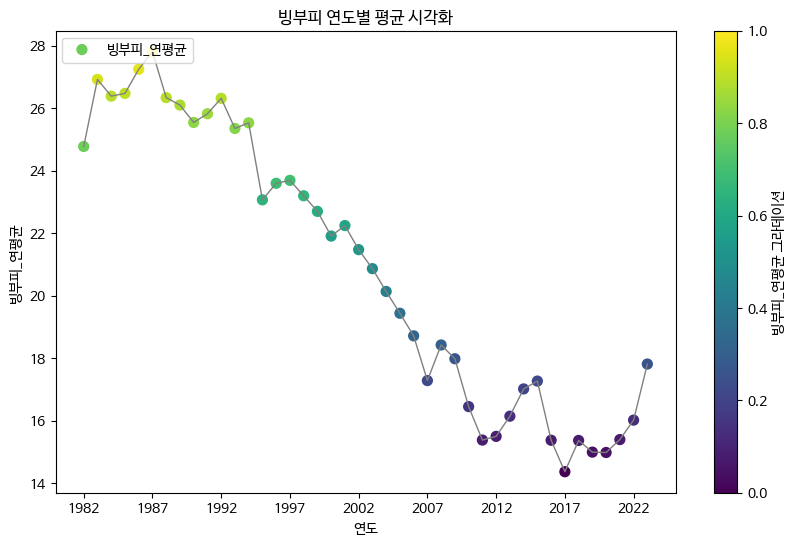

In [13]:
# 그래프를 생성하고 데이터를 산점도와 선 그래프로 플롯하세요
plt.figure(figsize=(10, 6))  # 그래프 크기 조정 (선택적)

# 색상 그라데이션 적용
cmap = plt.cm.get_cmap("viridis")
colors = gradient_color(yearly_data, cmap)

# 산점도로 표시
plt.scatter(yearly_data.index, yearly_data, c=colors, cmap="viridis", s=50, marker='o', label="빙부피_연평균")

# 선 그래프로 점들을 잇기
plt.plot(yearly_data.index, yearly_data, color="gray", linestyle='-', linewidth=1)

plt.title("빙부피 연도별 평균 시각화")  # 그래프 제목 설정 (선택적)
plt.xlabel("연도")  # x축 레이블 설정 (선택적)
plt.ylabel("빙부피_연평균")  # y축 레이블 설정 (선택적)

# X 축 눈금을 5년 주기로 설정
years = range(yearly_data.index.min(), yearly_data.index.max() + 1, 5)
plt.xticks(years)

# 컬러바 추가
cbar = plt.colorbar()
cbar.set_label("빙부피_연평균 그라데이션")

# 범례 추가
plt.legend(loc='upper left')

# 그래프를 표시하세요
plt.show()


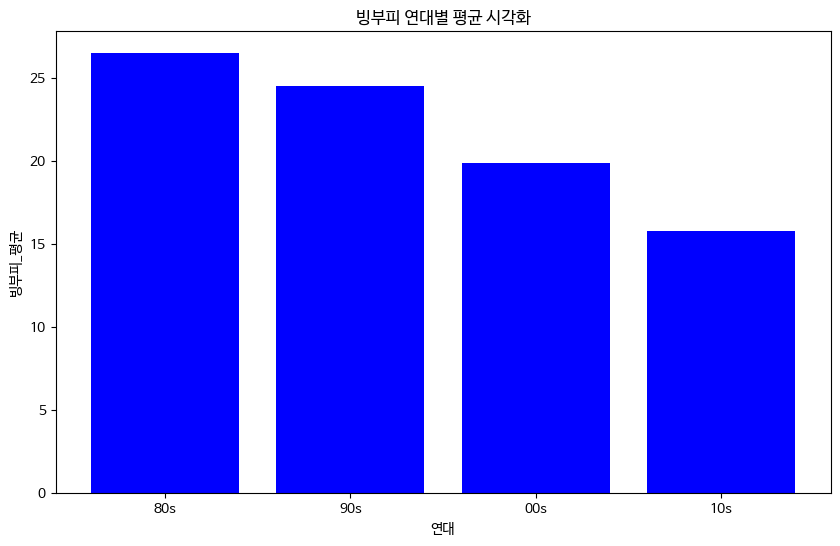

In [14]:
# 연도별로 그룹화하고 "해빙부피_MTH_AVG"의 평균을 계산
yearly_data = df.groupby(df["WTCH_YM"].dt.year)["해빙부피_MTH_AVG"].mean()

# 80년대, 90년대, 00년대, 10년대, 20년대의 평균 계산
years_80s = range(1980, 1990)
years_90s = range(1990, 2000)
years_00s = range(2000, 2010)
years_10s = range(2010, 2020)

average_80s = yearly_data[yearly_data.index.isin(years_80s)].mean()
average_90s = yearly_data[yearly_data.index.isin(years_90s)].mean()
average_00s = yearly_data[yearly_data.index.isin(years_00s)].mean()
average_10s = yearly_data[yearly_data.index.isin(years_10s)].mean()


# 그래프를 생성하고 데이터를 막대 그래프로 플롯하세요
plt.figure(figsize=(10, 6))  # 그래프 크기 조정 (선택적)

# 80년대, 90년대, 00년대, 10년대, 20년대의 평균을 막대 그래프로 표시
averages = [average_80s, average_90s, average_00s, average_10s]
years = ['80s', '90s', '00s', '10s']
plt.bar(years, averages, color='blue')

plt.title("빙부피 연대별 평균 시각화")  # 그래프 제목 설정 (선택적)
plt.xlabel("연대")  # x축 레이블 설정 (선택적)
plt.ylabel("빙부피_평균")  # y축 레이블 설정 (선택적)

# 그래프를 표시하세요
plt.show()

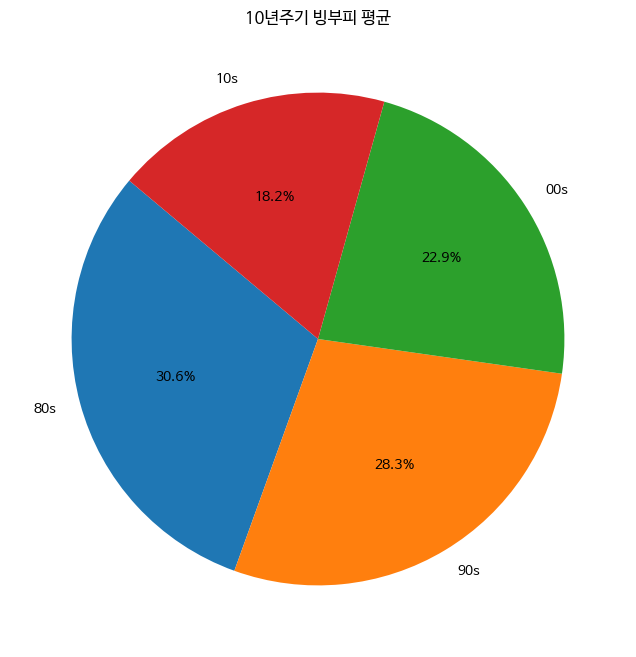

In [15]:
# 원 차트 그리기
plt.figure(figsize=(8, 8))  # 그래프 크기 조정 (선택적)
plt.pie(averages, labels=years, autopct='%1.1f%%', startangle=140)

#20s는 20~23뿐이라는 점 --> 20s뺄까???????? ㅋㅋㅋ
plt.title("10년주기 빙부피 평균")  # 그래프 제목 설정 (선택적)

# 그래프를 표시하세요
plt.show()